# The KdV equation with cubic splines, a Gauss method and OpenMP

We solve the Korteweg-de Vries (KdV) equation

$$u_t + u\,u_x + u_{xxx} = 0, \qquad -40 < x < 40, \quad 0 < t \le T,$$

with periodic boundary conditions. Its solitary wave

$$u(x, t) = 3c\,\mathrm{sech}^2\left(\tfrac{\sqrt{c}}{2}\,(x - c\,t)\right)$$

travels to the right with speed $c$. We take $c = 1$, so the wave has amplitude $3$. On the periodic domain of length $L = 80$ the exact solution is the periodic extension of the wave, computed as in `example3` from the crest and its two neighbors.

Multiplying by a periodic test function $v$ and integrating the term $u_{xxx}$ by parts once gives the weak form

$$\int u_t\, v \, dx = \int u_{xx}\, v' \, dx - \int u\,u_x\, v \, dx .$$

Cubic splines are $C^2$, so $u_{xx}$ is a continuous piecewise linear function and the right-hand side is well defined. In the spline space this is the system $M\,c'(t) = f(c)$ with the mass matrix $M$. The third derivative makes the system stiff, so we use an implicit method, the Gauss method with two stages (order 4), which also conserves the quadratic invariants of the semi-discrete system. Every step solves the stage equations by Newton's method, and both the stage iteration and the Newton iteration run in C++.

**OpenMP.** FEMd is built with OpenMP as in `example7` (`pip install . -C cmake.define.FEMD_OPENMP=ON`), and `fd.set_num_threads(k)` sets the number of threads. The first cell puts NumPy's own libraries on one thread and gives FEMd all the cores, so run it first in a fresh kernel. The results are the same for any number of threads, to the last digit. Without OpenMP the notebook runs on one thread.

In [1]:
import os
for var in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "OMP_NUM_THREADS"):
    os.environ.setdefault(var, "1")                 # NumPy's libraries on one thread; FEMd sets its own count

import time
import numpy as np
import matplotlib.pyplot as plt
import femd as fd
from femd import D, dx

ncores = os.cpu_count() if fd.has_openmp() else 1
fd.set_num_threads(ncores)
print("OpenMP:", fd.has_openmp(), "  threads:", fd.get_num_threads())

OpenMP: True   threads: 11


Periodic cubic splines on 4000 equal elements of $[-40, 40]$, and the solitary wave at $t = 0$ as the initial condition.

In [2]:
grid = np.linspace(-40, 40, 4001)
V = fd.SplineSpace(grid, 3, bc="periodic")
u, v = fd.TrialFunction(V), fd.TestFunction(V)

c = 1.0
a, b = grid[0], grid[-1]
L = b - a                                         # the period

def exact(x, t, cosh=np.cosh):
    """The periodic solitary wave at time t. x is an array (cosh=np.cosh) or fd.x (cosh=fd.cosh)."""
    s = (c * t - a) % L + a                       # the crest c t, moved back into [a, b)
    return sum(3 * c / cosh(np.sqrt(c) / 2 * (x - s - k * L))**2 for k in (-1, 0, 1))

w = fd.Function(V, "w")
w.project(exact(fd.x, 0.0, fd.cosh))
w0 = w.vector.copy()                              # the initial coefficients, to restart from
print(V.dim, "unknowns")

4000 unknowns


The two sides of the weak form, `M` the mass matrix and `f` the right-hand side, nonlinear in `w`. `D(w, 2)` is the second derivative, available on cubic splines.

KdV conserves $I_1 = \int u\,dx$, $I_2 = \int u^2\,dx$ and $I_3 = \int \left(\tfrac{1}{3}u^3 - u_x^2\right) dx$. The Gauss method conserves $I_1$ and $I_2$ of the semi-discrete system exactly, $I_3$ up to the time-stepping error.

In [3]:
M = fd.form(u * v * dx)
f = fd.form((D(w, 2) * D(v) - w * D(w) * v) * dx)

I1 = fd.form(w * dx)
I2 = fd.form(w**2 * dx)
I3 = fd.form((w**3 / 3 - D(w)**2) * dx)
I1_0, I2_0, I3_0 = I1.assemble(), I2.assemble(), I3.assemble()
print("I1 =", I1_0, "  I2 =", I2_0, "  I3 =", I3_0)

I1 = 11.999999999999972   I2 = 24.00000000000002   I3 = 14.399999999999999


**The run.** `fd.IRK` with `"gauss"` and two stages solves the stage equations by Newton's method with the exact Jacobian of `f`, assembled at every iteration. We take $\Delta t = 0.05$ up to $T = 40$, so the wave travels half the period, compare with the exact solution and check the invariants. `info` is the `NewtonInfo` of the last step.

800 steps on 11 thread(s) in 18.5 s
NewtonInfo(converged in 3 iterations, ||R|| 1.85e-02 -> 1.45e-11, converged on the step: the error left is below xtol, ||F|| is at its round-off floor)
max error:    3.71895343409534e-07
change in I1: 6.412648190234904e-13
change in I2: 8.949285756898462e-12
change in I3: 8.926193117986259e-12


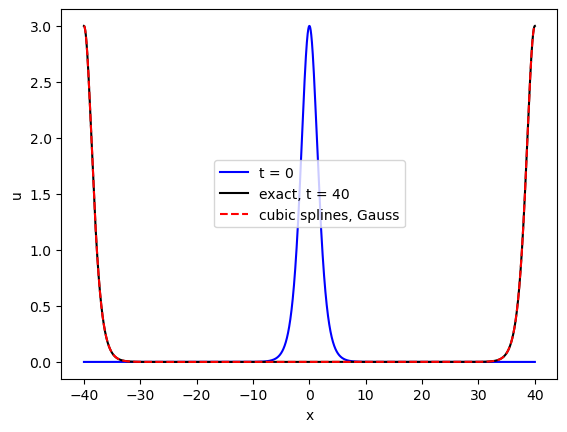

In [4]:
dt, T = 0.05, 40.0
irk = fd.IRK(M, f, dt, "gauss", 2)

t0 = time.perf_counter()
for n in range(int(round(T / dt))):
    info = irk.step(w)
print(f"{int(round(T / dt))} steps on {ncores} thread(s) in {time.perf_counter() - t0:.1f} s")
print(info)

t = irk.t
xs = np.linspace(-40, 40, 8001)
uexact = exact(xs, t)
print("max error:   ", np.max(np.abs(w(xs) - uexact)))
print("change in I1:", abs(I1.assemble() - I1_0))
print("change in I2:", abs(I2.assemble() - I2_0))
print("change in I3:", abs(I3.assemble() - I3_0))

u0 = fd.Function(V, w0)                           # the initial condition, from the saved coefficients
plt.plot(xs, u0(xs), "b-", label="t = 0")
plt.plot(xs, uexact, "k-", label=f"exact, t = {t:g}")
plt.plot(xs, w(xs), "r--", label="cubic splines, Gauss")
plt.xlabel("x"); plt.ylabel("u"); plt.legend()
plt.show()